#  Reviews Sentiment - Bidirectional LSTM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
import re, string, nltk
import emoji, bz2

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import word_tokenize

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, LSTM, Bidirectional, Dropout, Embedding

from keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2026-05-07 05:17:48.478342: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778131068.673568      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778131068.734041      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778131069.211584      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778131069.211622      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778131069.211625      57 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rizwanali324/amazon-review-sentiment/Amazon_review.csv")
df.head()

,Unnamed: 0,review,sentiment
0,1959029,I just adopted a chocolate lab who loves to sn...,1
1,971879,Watched it and wasn't very impressed. It was t...,0
2,44681,"By 1967, enough was enough with the light fluf...",0
3,793119,I was interested in what all the hype was abou...,0
4,2921599,I expected a well written book (as someone rec...,0


In [3]:
df = df[["review","sentiment"]]
df

,review,sentiment
0,I just adopted a chocolate lab who loves to sn...,1
1,Watched it and wasn't very impressed. It was t...,0
2,"By 1967, enough was enough with the light fluf...",0
3,I was interested in what all the hype was abou...,0
4,I expected a well written book (as someone rec...,0
...,...,...
100795,I purchased this product for my 1 year old twi...,0
100796,"When reading this book, you will probably find...",1
100797,This video has some really great tunes the muc...,1
100798,"I did finish the movie, but it was only rallyi...",0


In [4]:
# shape of data
df.shape

(100800, 2)

In [5]:
# checking for null values
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [6]:
# dropping null values
df = df.dropna()

In [7]:
# checking for any duplicate in the data
df.duplicated().sum()

np.int64(4)

In [8]:
df.sentiment.value_counts()

sentiment
1    50515
0    50285
Name: count, dtype: int64

* Classes are balanced. So, no need for oversampling or undersampling the target column.

# Cleaning Data

In [9]:
# import re
# import emoji
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

# Load once for better performance
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    #  Convert text to lowercase
    text = text.lower()

    # Replace short forms
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)

    #  Remove URLs
    text = re.sub(r"http\S+", "", text)

    #  Remove emojis
    text = emoji.replace_emoji(text, replace='')

    #  Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    #  Split sentence into words
    words = text.split()

    #  Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    #  Join words back into sentence
    return ' '.join(words)

In [10]:
df["clean_review"] = df["review"].apply(clean_text)
df.head(15)

,review,sentiment,clean_review
0,I just adopted a chocolate lab who loves to sn...,1,adopted chocolate lab love snuggle rub furnitu...
1,Watched it and wasn't very impressed. It was t...,0,watched impressed taken min less tv show calle...
2,"By 1967, enough was enough with the light fluf...",0,enough enough light fluff comedy starring elvi...
3,I was interested in what all the hype was abou...,0,interested hype like book nicely banded pretty...
4,I expected a well written book (as someone rec...,0,expected well written book someone recommended...
5,This is a great little feeder for a window. Si...,1,great little feeder window simple basic design...
6,I know that everyone thinks that the exorcist ...,0,know everyone think exorcist best film ever ma...
7,Twp of my favorite stars -- Clair Danes and Je...,0,twp favorite star clair dane jennifer lopez to...
8,This item was ordered for me as a birthday gif...,0,item ordered birthday gift june september stil...
9,"The product was shipped in good time, but I wa...",0,product shipped good time dissappointed tea re...


### WordClouds
* Useful for viewing and analyzing words that are frequently used.

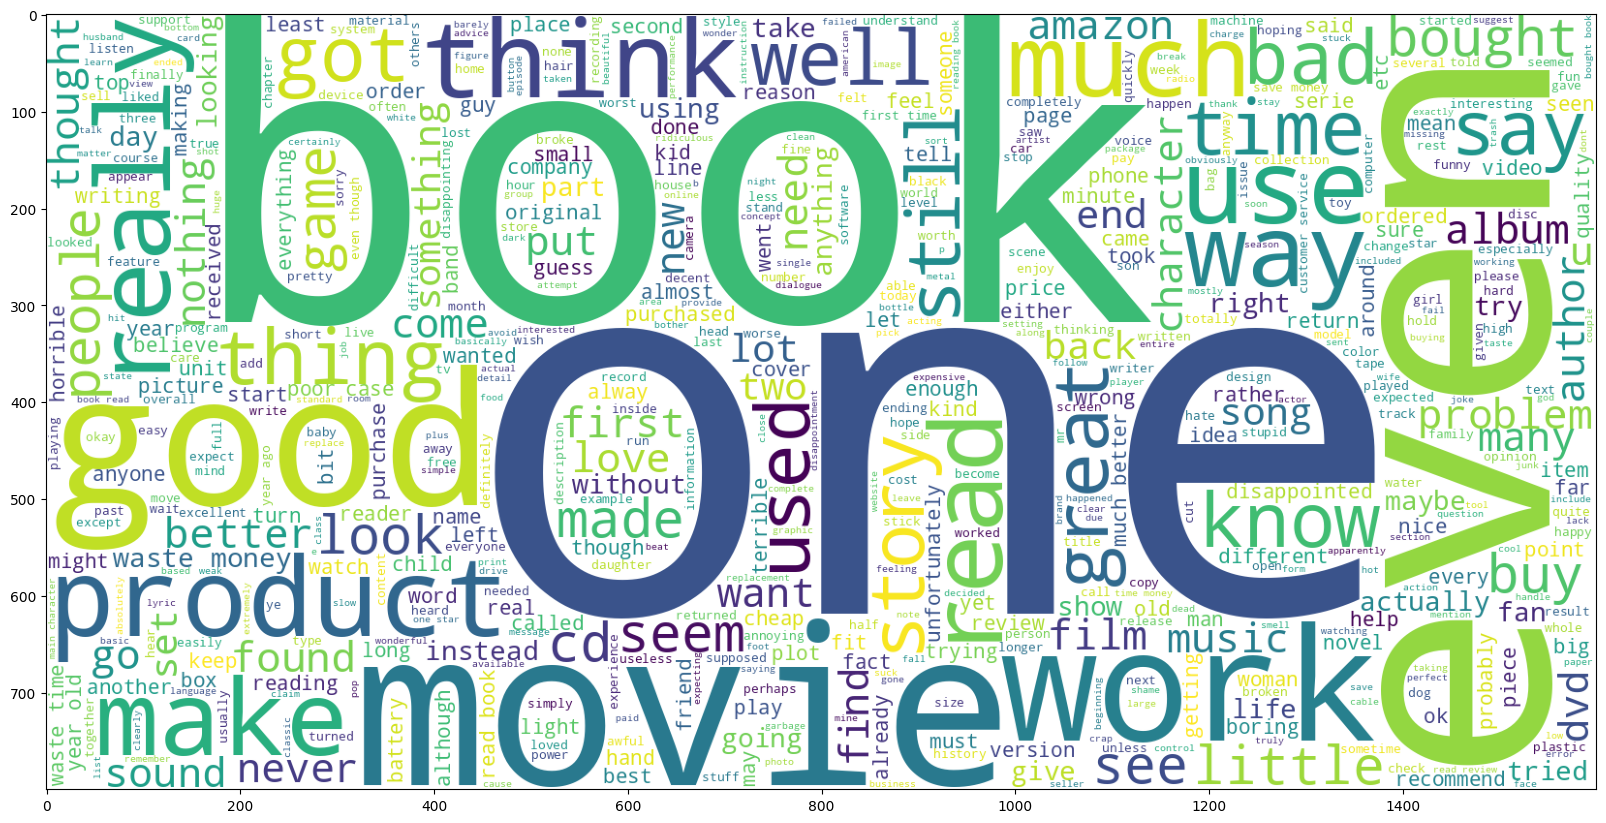

In [11]:
# Negative Review WordCloud
plt.figure(figsize=(20,20))
wc1 = WordCloud(max_words=2000,min_font_size=10, height=800, width=1600, 
               background_color="white").generate(" ".join(df[df["sentiment"]==0].clean_review))
plt.imshow(wc1)

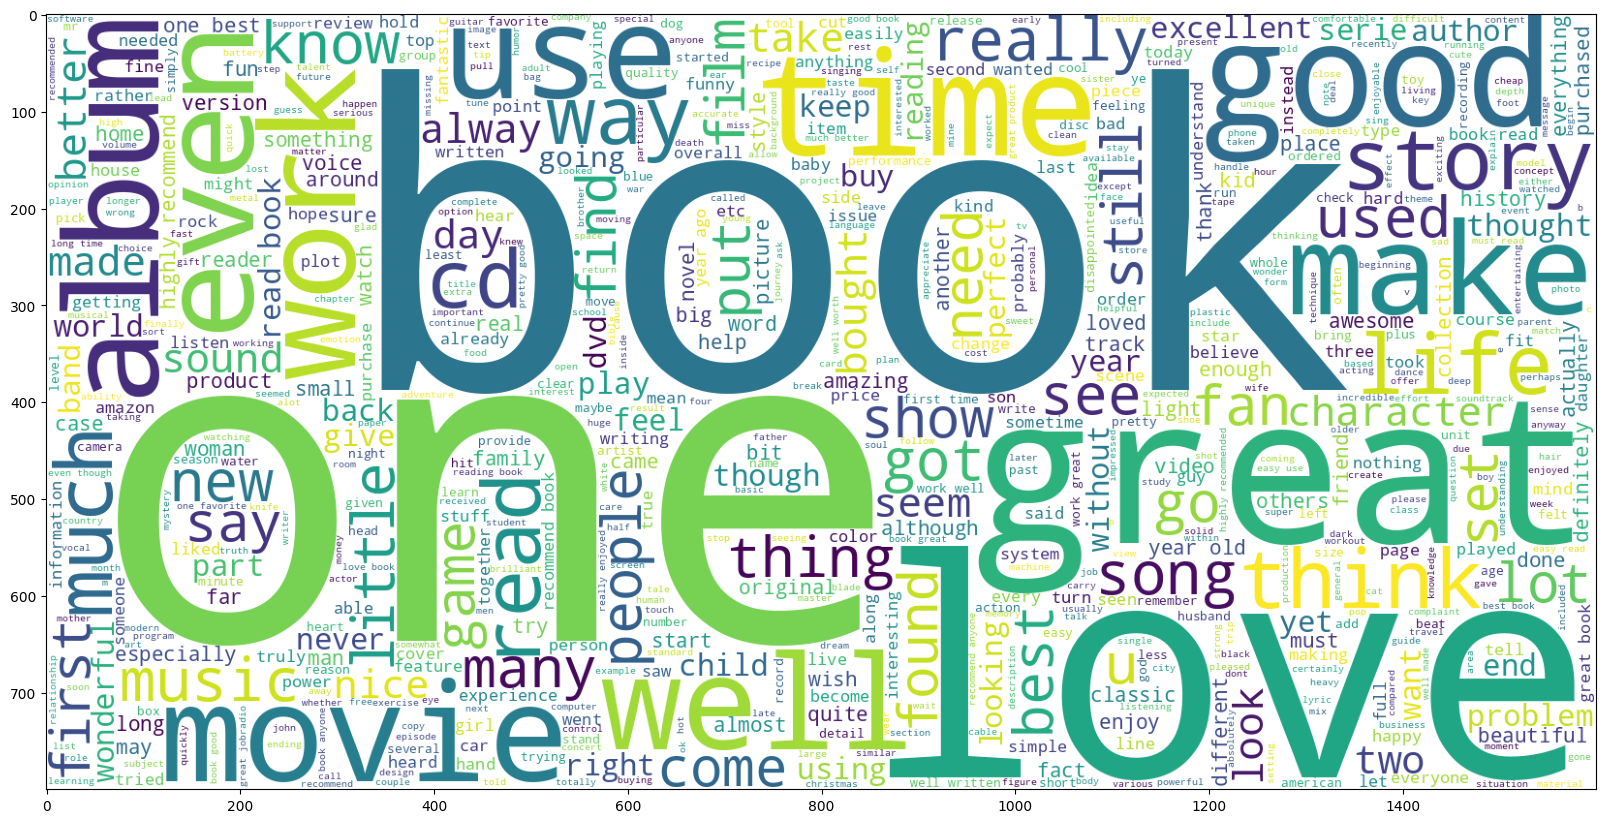

In [12]:
# Positive Review WordCloud
plt.figure(figsize=(20,20))
wc = WordCloud(max_words=2000,min_font_size=10, height=800, width=1600, 
               background_color="white").generate(" ".join(df[df["sentiment"]==1].clean_review))
plt.imshow(wc)

In [13]:
df = df[["sentiment","clean_review"]]
df.head(10)

,sentiment,clean_review
0,1,adopted chocolate lab love snuggle rub furnitu...
1,0,watched impressed taken min less tv show calle...
2,0,enough enough light fluff comedy starring elvi...
3,0,interested hype like book nicely banded pretty...
4,0,expected well written book someone recommended...
5,1,great little feeder window simple basic design...
6,0,know everyone think exorcist best film ever ma...
7,0,twp favorite star clair dane jennifer lopez to...
8,0,item ordered birthday gift june september stil...
9,0,product shipped good time dissappointed tea re...


# Model Training


* Applying tokenizer for Bi-LSTM input after splitting data into training and testing/validation set.

In [14]:
from sklearn.model_selection import train_test_split
X = df["clean_review"]
y = df.sentiment
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
display(X_train.shape)
display(X_test.shape)

(75600,)

(25200,)

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

In [16]:

# using tokenizer to transform text messages into training and testing set
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [17]:

X_train_seq_padded = pad_sequences(X_train_seq, maxlen=64)
X_test_seq_padded = pad_sequences(X_test_seq, maxlen=64)

In [18]:
X_train_seq_padded[0]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     8,   243,     1,   137,    32,  2617, 25923,
          39,    66,   195,    98,    15,  1915,  2840,    98,    15,
        1915], dtype=int32)

### Bidirectional LSTM
* Structure and Parameters

In [19]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense

# construct model
BATCH_SIZE = 64
vocab_size = len(tokenizer.index_word) + 1   # total words in vocabulary (+1 for padding token)
embedding_dim = 64                           # size of word vector
max_sequence_length = 64                     # same as padding length

model = Sequential()

#  Embedding Layer (Word → Vector)
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_sequence_length
))

#  LSTM Layer (understands sequence)
model.add(Bidirectional(LSTM(100)))

#  Hidden Dense Layer
model.add(Dense(128, activation="relu"))

#  Output Layer (binary classification)
model.add(Dense(1, activation="sigmoid"))

model.compile("adam","binary_crossentropy",metrics=["accuracy"])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1778131170.919834      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Used for preventing ovefitting
from keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss",patience=5,verbose=True)

In [21]:
history = model.fit(X_train_seq_padded, y_train,batch_size=BATCH_SIZE,epochs=15,
                    validation_data=(X_test_seq_padded, y_test),callbacks=[early_stop])

Epoch 1/15


I0000 00:00:1778131174.992489     132 cuda_dnn.cc:529] Loaded cuDNN version 91002


1182/1182 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7714 - loss: 0.4560 - val_accuracy: 0.8550 - val_loss: 0.3348
Epoch 2/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9085 - loss: 0.2324 - val_accuracy: 0.8475 - val_loss: 0.3665
Epoch 3/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9420 - loss: 0.1528 - val_accuracy: 0.8412 - val_loss: 0.4288
Epoch 4/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9655 - loss: 0.0949 - val_accuracy: 0.8339 - val_loss: 0.4977
Epoch 5/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9794 - loss: 0.0591 - val_accuracy: 0.8316 - val_loss: 0.6682
Epoch 6/15
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9871 - loss: 0.0366 - val_accuracy: 0.8233 - val_loss: 0.7223
Epoch 6: early stopping


In [ ]:
from sklearn.metrics import roc_auc_score

# Predictions
train_pred = model.predict(X_train_seq_padded)
test_pred = model.predict(X_test_seq_padded)

# AUC Score
print("Train AUC:", roc_auc_score(y_train, train_pred))
print("Test AUC:", roc_auc_score(y_test, test_pred))

# Model evaluation
model.evaluate(X_test_seq_padded, y_test)

Text(0.5, 1.0, 'Training and Validation Accuracy')

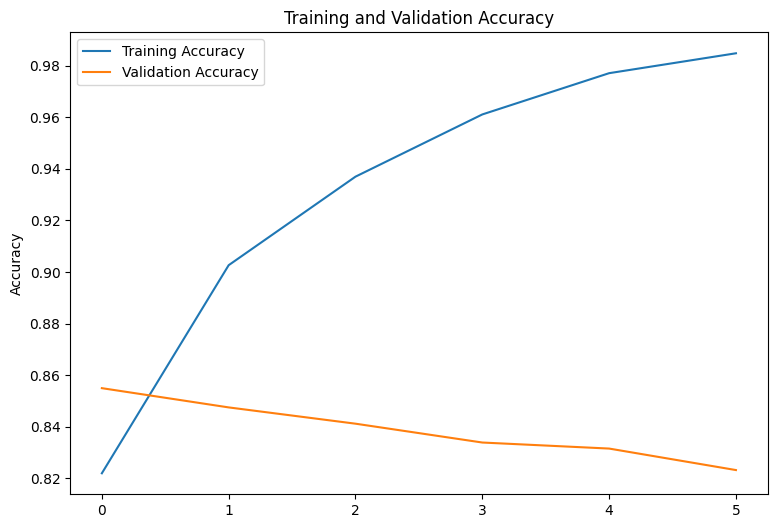

In [24]:
acc = history.history["accuracy"]
loss = history.history["loss"]

val_acc = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(9,6))
plt.plot(acc,label="Training Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

Text(0.5, 1.0, 'Training and Validation Loss')

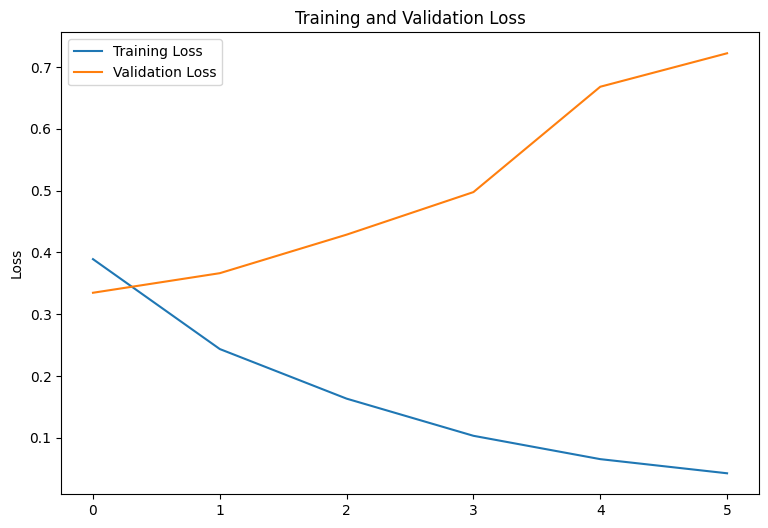

In [25]:
plt.figure(figsize=(9,6))
plt.plot(loss,label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.legend()
plt.ylabel("Loss")
plt.title("Training and Validation Loss")